#**Summary**

This notebook builds the data foundation for a sparse index-tracking project on the S&P 500. The pipeline covers data collection, integrity checks, preprocessing into a model-ready format, and exploratory visualization. The work is structured to be reproducible and to make every methodological choice explicit, so that downstream modeling can rely on a documented dataset rather than ad-hoc downloads.

**Universe construction.** I assembled the full historical universe of all 729 tickers that appeared in the S&P 500 at any point during the analysis period 2016-01-01 to 2026-01-14, using the point-in-time constituent file from the fja05680/sp500 repository. This addresses survivorship bias at the design stage: every candidate asset that was ever a part of the index is included, not only those that survived to the present.

**Price data.** Daily adjusted close prices were downloaded for all 729 tickers via yfinance, with batched downloads, exponential-backoff retries, and a second pass on failed tickers. 612 of 729 (84.0%) were retrieved successfully; the remaining 117 are predominantly companies that were acquired or delisted during the period and are no longer maintained by yfinance. This residual survivorship bias is documented explicitly in `failed_tickers.csv` rather than concealed.

**Index change history.** A second source — the Wikipedia "Selected changes to the list of S&P 500 components" — was parsed to obtain 417 add/drop events during the period, with the underlying reason classified into six categories (M&A, Spin-off, Market cap, Bankruptcy, Other, Unknown). M&A dominated (47%), followed by quarterly market-capitalization adjustments (38%).

**Data quality diagnostics.** Per-ticker availability was characterized along two coverage metrics, and one anomalous ticker (`CCE`) was identified by an outlier in `coverage_from_first`. Further investigation traced the anomaly to a likely symbol reuse on Yahoo Finance; the ticker was excluded from the modeling universe. No further data was filtered, leaving 611 tickers in the final universe.

**ML-ready output.** Daily prices were resampled to weekly frequency using the Friday-close convention, and simple returns were computed for both the asset universe and the `^SP500TR` benchmark index. The aligned dataset contains 523 weekly observations across 611 assets.

**Exploratory visualizations.** Four views summarize the data: the index path with major market events, the highly concentrated market-cap distribution within the index (top 16 firms cover 50%, top 10 cover 43%), the meaningful divergence between cap-weighted and equal-weighted strategies (SPY 14.97% vs RSP 11.97% CAGR), and the time-varying composition of the universe driven by IPOs, spin-offs, and delistings.

**Persisted artifacts.** All key tables — raw prices, the index series, the constituents history, the index change events, the ticker availability metrics, and the ML-ready weekly returns — are saved to Google Drive in Parquet format.

#Imports and Setup

This block installs and imports all libraries used in the project.

**Library groups:**
- Data manipulation: `pandas`, `numpy`, `requests`, etc
- Market data: `yfinance`, etc
- Optimization: `cvxpy`, `scipy.optimize`, etc
- Visualization: `matplotlib`, `seaborn`, etc
- Utilities: `tqdm`, `warnings`, `os`, `time`, etc

In [48]:
!pip install yfinance --quiet
!pip install cvxpy --quiet

import os
import re
import time
import warnings
from io import StringIO

import numpy as np
import pandas as pd
import requests

import yfinance as yf

import cvxpy as cp
from scipy import optimize as sp_optimize

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

from google.colab import drive

RANDOM_SEED = 100
np.random.seed(RANDOM_SEED)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

drive.mount('/content/drive', force_remount=False)

PROJECT_DIR = '/content/drive/MyDrive/ml_finance_project_index_tracking'
CACHE_DIR = f'{PROJECT_DIR}/cache'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")
print(f"yfinance:   {yf.__version__}")
print(f"CVXPY:      {cp.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/ml_finance_project_index_tracking
NumPy:      2.0.2
Pandas:     2.2.2
yfinance:   0.2.66
CVXPY:      1.6.7


#Data Import

**Analysis period:** 2016-01-01 to 2026-01-14 (approximately 10 years)

**Index source:** Since the official historical composition data for the S&P 500 index is not publicly available, I use the regularly updated GitHub repository fja05680 (https://github.com/fja05680/sp500) as our source. At the time of writing, the repository is actively maintained, distributed under the MIT license, and widely used in the open-source community (846 stars at the time of writing). Its base dataset originates from Andreas Clenow's "Trading Evolved" and is updated through regular cross-checks against Wikipedia.

In [49]:
# Raw CSV from the fja05680/sp500 repository
CONSTITUENTS_URL = (
    'https://raw.githubusercontent.com/fja05680/sp500/master/'
    'S%26P%20500%20Historical%20Components%20%26%20Changes(01-17-2026).csv'
)

# Download and parse
response = requests.get(CONSTITUENTS_URL, timeout=30)
response.raise_for_status()
constituents_raw = pd.read_csv(StringIO(response.text))
constituents_raw['date'] = pd.to_datetime(constituents_raw['date'])

print(f"Shape: {constituents_raw.shape}")
constituents_raw.head()

Shape: (2705, 2)


,date,tickers
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."


**Period Filtering and Universe Construction**

From the historical table:
- **Step 1**. Select the rows that fall within the analysis period 2016-01-01 to 2026-01-14.
- **Step 2**. Additionally include the last row before 2016-01-01 to capture the index composition at the start of the period.
- **Step 3**. Merge all ticker lists into a single unique universe — this is the set of candidate assets for the tracking portfolio.

In [50]:
# Analysis period
START_DATE = pd.Timestamp('2016-01-01')
END_DATE   = pd.Timestamp('2026-01-14')

# Step 1
in_period = constituents_raw[
    (constituents_raw['date'] >= START_DATE) &
    (constituents_raw['date'] <= END_DATE)
].copy()

# Step 2
before_start = constituents_raw[constituents_raw['date'] < START_DATE]
if len(before_start) > 0:
    initial_row = before_start.tail(1).copy()
    constituents = pd.concat([initial_row, in_period], ignore_index=True)
else:
    constituents = in_period.reset_index(drop=True)

# Step 3
all_tickers = set()
for tickers_str in constituents['tickers']:
    all_tickers.update(t.strip() for t in tickers_str.split(','))

universe = sorted(all_tickers)

# Summary
print(f"Rows in analysis period:               {len(in_period)}")
print(f"Total rows (incl. initial state):      {len(constituents)}")
print(f"Unique tickers in universe:            {len(universe)}")
print(f"\nFirst 20 tickers: {universe[:20]}")

Rows in analysis period:               474
Total rows (incl. initial state):      475
Unique tickers in universe:            729

First 20 tickers: ['A', 'AABA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABMD', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'ADT', 'AEE']


**Daily Price Download via yfinance**

**Data versions:**
- Index: `^SP500TR` (S&P 500 Total Return Index) — includes dividend reinvestment.
- Stocks: daily Adjusted Close via yfinance with `auto_adjust=True`. The Adjusted Close accounts for dividends and splits, producing total return when used to compute returns.

**Download strategy:**
- Batches of 20 tickers with a 3-second pause between requests to respect Yahoo Finance rate limits.
- Retry with exponential backoff on HTTP errors.
- A second pass over failed tickers individually to distinguish transient failures from true data unavailability.
- Intermediate checkpointing to Google Drive after each batch for fault tolerance.

Tickers containing a dot (e.g., `BRK.B`) are converted to the Yahoo format (`BRK-B`).

In [51]:
INDEX_TICKER = '^SP500TR'  # S&P 500 Total Return Index

index_data = yf.download(
    INDEX_TICKER,
    start=START_DATE,
    end=END_DATE + pd.Timedelta(days=1),
    auto_adjust=True,
    progress=False,
    threads=False,
    multi_level_index=False,
)

print(f"Index columns:  {index_data.columns.tolist()}")
print(f"Index shape:    {index_data.shape}")
print(f"Date range:     {index_data.index.min().date()} to {index_data.index.max().date()}")

index_data.head()

Index columns:  ['Close', 'High', 'Low', 'Open', 'Volume']
Index shape:    (2523, 5)
Date range:     2016-01-04 to 2026-01-14


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,"3,763.9900","3,811.7400","3,721.0400","3,811.7400",0
2016-01-05,"3,771.5701","3,781.2700","3,748.1499","3,766.0801",0
2016-01-06,"3,723.4399","3,763.5500","3,702.4700","3,763.5500",0
2016-01-07,"3,635.2900","3,714.2900","3,627.3201","3,714.2900",0
2016-01-08,"3,595.9099","3,667.6799","3,589.4600","3,640.6899",0


**Price Data Download**

This cell downloads daily Adjusted Close prices for all 729 tickers in the universe via the `yfinance` API. The procedure is organized into five sections:

**Step 1. Parameters and universe preparation.** Define batch size, sleep intervals, retry limits, and the checkpoint frequency. Ticker symbols are converted to the Yahoo Finance format (e.g., `BRK.B` becomes `BRK-B`), and a two-way mapping between the original and Yahoo-formatted tickers is kept for traceability.

**Step 2. Helper functions.** Two utilities are defined:
- `download_batch` performs a single `yf.download` call for a list of tickers, with up to `MAX_RETRIES` attempts and exponential backoff (10s, 20s, 40s) on errors.
- `extract_close_from_batch` parses the multi-ticker response from yfinance and returns a dictionary `{ticker: Close series}` together with a list of tickers for which extraction failed.

**Step 3. Main pass.** The universe is split into batches of 20 tickers, and each batch is downloaded sequentially with a 3-second pause between batches to respect Yahoo Finance rate limits. After every 5 batches, partial results are saved to `prices_partial.parquet` on Google Drive as a checkpoint, providing fault tolerance against session timeouts or network failures.

**Step 4. Retry pass.** Tickers that failed during the main pass are retried individually with a 1.5-second pause between requests. This pass serves a diagnostic purpose: a ticker that recovers here was lost due to a transient failure (rate limit, timeout, or a problematic neighbor in the batch), while a ticker that fails again is treated as truly unavailable on Yahoo Finance (typically a delisted or renamed security).

**Step 5. Final assembly.** All successfully downloaded Close series are combined into a single `prices_daily` DataFrame indexed by trading date, with one column per ticker. A summary reports the number of recovered tickers, the share of the universe with available data, and the date range covered.

In [52]:
# Step 1

BATCH_SIZE = 20
SLEEP_BETWEEN_BATCHES = 3.0
SLEEP_BETWEEN_RETRIES = 1.5
MAX_RETRIES = 3
CHECKPOINT_EVERY = 5

# Yahoo Finance uses '-' instead of '.' (e.g., BRK.B -> BRK-B)
def to_yahoo_ticker(t):
    return t.replace('.', '-')

yf_to_original = {to_yahoo_ticker(t): t for t in universe}
yf_tickers_list = list(yf_to_original.keys())
print(f"Universe size: {len(yf_tickers_list)}")


# Step 2

def download_batch(tickers_batch, retries=MAX_RETRIES):
    for attempt in range(retries):
        try:
            data = yf.download(
                tickers_batch,
                start=START_DATE,
                end=END_DATE + pd.Timedelta(days=1),
                auto_adjust=True,
                progress=False,
                threads=False,
                group_by='ticker',
            )
            return data, None
        except Exception as e:
            if attempt < retries - 1:
                wait = 10 * (2 ** attempt)
                time.sleep(wait)
            else:
                return None, str(e)
    return None, 'max retries exceeded'


def extract_close_from_batch(data, tickers_batch):
    closes = {}
    failed = []
    for tkr in tickers_batch:
        try:
            if len(tickers_batch) == 1:
                if isinstance(data.columns, pd.MultiIndex):
                    series = data[('Close', tkr)] if ('Close', tkr) in data.columns else data['Close']
                else:
                    series = data['Close']
            else:
                series = data[tkr]['Close']

            series = series.dropna()
            if len(series) < 10:
                failed.append((tkr, f'too_few_obs={len(series)}'))
            else:
                closes[tkr] = series
        except (KeyError, AttributeError) as e:
            failed.append((tkr, f'extract_error: {type(e).__name__}'))
    return closes, failed


# Step 3

batches = [yf_tickers_list[i:i + BATCH_SIZE]
           for i in range(0, len(yf_tickers_list), BATCH_SIZE)]

print(f"Main pass: {len(yf_tickers_list)} tickers in {len(batches)} batches of {BATCH_SIZE}")

all_close = {}
failed_tickers = []

for i, batch in enumerate(tqdm(batches, desc='Main pass')):
    data, err = download_batch(batch)
    if data is None or len(data) == 0:
        for tkr in batch:
            failed_tickers.append((tkr, f'batch_failed: {err}'))
    else:
        closes, batch_failed = extract_close_from_batch(data, batch)
        all_close.update(closes)
        failed_tickers.extend(batch_failed)

    if (i + 1) % CHECKPOINT_EVERY == 0:
        pd.DataFrame(all_close).to_parquet(f'{CACHE_DIR}/prices_partial.parquet')

    time.sleep(SLEEP_BETWEEN_BATCHES)

print(f"\nMain pass complete:")
print(f"  Successfully downloaded: {len(all_close)}")
print(f"  Failed: {len(failed_tickers)}")


# Step 4

if len(failed_tickers) > 0:
    print(f"\nRetry pass: {len(failed_tickers)} tickers individually")
    still_failed = []
    recovered = 0
    failed_list_only = [t for t, _ in failed_tickers]

    for tkr in tqdm(failed_list_only, desc='Retry pass'):
        data, err = download_batch([tkr], retries=2)
        if data is not None and len(data) > 0:
            closes, batch_failed = extract_close_from_batch(data, [tkr])
            if closes:
                all_close.update(closes)
                recovered += 1
            else:
                reason = batch_failed[0][1] if batch_failed else 'unknown'
                still_failed.append((tkr, reason))
        else:
            still_failed.append((tkr, f'retry_failed: {err}'))
        time.sleep(SLEEP_BETWEEN_RETRIES)

    print(f"\nRetry pass complete:")
    print(f"  Recovered: {recovered}")
    print(f"  Still failed: {len(still_failed)}")
    failed_tickers = still_failed


# Step 5

prices_daily = pd.DataFrame(all_close).sort_index()
prices_daily.index = pd.to_datetime(prices_daily.index)

print(f"\nFinal Results")
print(f"Universe size:        {len(yf_tickers_list)}")
print(f"Successfully loaded:  {prices_daily.shape[1]} ({prices_daily.shape[1] / len(yf_tickers_list) * 100:.1f}%)")
print(f"Failed:               {len(failed_tickers)} ({len(failed_tickers) / len(yf_tickers_list) * 100:.1f}%)")
print(f"Date range:           {prices_daily.index.min().date()} to {prices_daily.index.max().date()}")

Universe size: 729
Main pass: 729 tickers in 37 batches of 20


Main pass:   0%|          | 0/37 [00:00<?, ?it/s]

ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['AABA', 'ABMD', 'ABC', 'ADS']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['ALXN', 'AGN']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['ANTM', 'ANSS']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['APC']: YFPricesMissingError('possibly delisted; no price data found  (1d 2016-01-01 00:00:00 -> 2026-01-15 00:00:00) (Yahoo error = "Data doesn\'t exist for startDate = 1451624400, endDate = 1768453200")')
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['ATVI', 'ARNC']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['ARG']: YFPricesMissingError('possibly delisted; no price data found  (1d 2016-01-01 00:00:00 -> 2026-01-15 00:00:00)')
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['BRCM', 'BCR']: YFPricesMissingError('possibly delisted; no price data f


Main pass complete:
  Successfully downloaded: 612
  Failed: 117

Retry pass: 117 tickers individually


Retry pass:   0%|          | 0/117 [00:00<?, ?it/s]

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AABA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ABC']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ABMD']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ADS']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AGN']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ALXN']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ANSS']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ANTM']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['APC']: YFPrices


Retry pass complete:
  Recovered: 0
  Still failed: 117

Final Results
Universe size:        729
Successfully loaded:  612 (84.0%)
Failed:               117 (16.0%)
Date range:           2016-01-04 to 2026-01-14


**Index Change History from Wikipedia**

To document the dynamics of the S&P 500 composition over the analysis period, I retrieve the table of historical index changes from the Wikipedia article ["List of S&P 500 companies"](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies). The page contains a section "Selected changes to the list of S&P 500 components" listing composition changes with a stated reason (acquisition, spin-off, market capitalization adjustment, bankruptcy, etc.).

**Source issue.** The Wikipedia table is community-maintained and explicitly labeled as "selected" changes — completeness is not guaranteed, and the `Reason` field is occasionally missing. For events with no reason text, I record `unknown`.

**Processing pipeline:**

- **Step 1. Fetch HTML.** Request the Wikipedia page with a proper User-Agent header — Wikipedia blocks requests with generic UAs.

- **Step 2. Parse tables.** Extract all tables via `pd.read_html`; the changes table is the second one on the page.

- **Step 3. Flatten columns.** The changes table has MultiIndex columns (`Added` and `Removed` are header groups over `Ticker`/`Security`). Flatten to single-level names.

- **4. Clean Reason.** Strip Wikipedia footnote references (e.g., `[6][7]`) from the reason text.

- **5. Explode into events.** Convert from "one row per replacement" to "one row per add/drop event". A single Wikipedia row may contain an added security, a removed security, or both.

- **6. Filter to analysis period.** Keep only events within 2016-01-01 to 2026-01-14.

- **7. Classify reasons.** Map the raw reason text to one of six coarse categories — `M&A`, `Spin-off`, `Market cap`, `Bankruptcy`, `Other`, `Unknown` — using keyword matching.

The resulting DataFrame `index_changes` has columns: `date`, `action` (`add`/`drop`), `ticker`, `company`, `reason` (raw), `reason_category` (classified).

In [53]:
WIKI_URL = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (compatible; MLFinanceIndexTracking/1.0; '
        'contact: axtheg@gmail.com)'
    )
}

KW_BANKRUPTCY = ['fdic', 'receivership', 'bankruptcy', 'chapter 11']
KW_MARKET_CAP = ['market capitalization', 'market cap']
KW_SPINOFF    = ['spun off', 'spin-off', 'spinoff']
KW_MA = [
    'acquired', 'acquiring', 'acquires', 'acquisition',
    'merger', 'merge', 'merges', 'merged', 'merging',
    'taken over', 'takeover', 'buyout', 'bought by',
]


def clean_reason(text):
    """Strip Wikipedia footnote references like [6][7] from the reason text."""
    if pd.isna(text):
        return None
    text = re.sub(r'\[\d+\]', '', str(text)).strip()
    return text if text else None


def classify_reason(row):
    """Map a Wikipedia reason text to a coarse category.

    Returns one of: 'Bankruptcy', 'Market cap', 'Spin-off', 'M&A',
    'Other', 'Unknown'. More specific patterns are checked first.
    """
    reason = row['reason']
    if pd.isna(reason) or reason == '':
        return 'Unknown'

    text = reason.lower()
    if any(kw in text for kw in KW_BANKRUPTCY):
        return 'Bankruptcy'
    if any(kw in text for kw in KW_MARKET_CAP):
        return 'Market cap'
    if any(kw in text for kw in KW_SPINOFF):
        return 'Spin-off'
    if any(kw in text for kw in KW_MA):
        return 'M&A'
    return 'Other'


# Step 1
wiki_response = requests.get(WIKI_URL, headers=HEADERS, timeout=30)
wiki_response.raise_for_status()
tables = pd.read_html(StringIO(wiki_response.text))


# Step 2
changes_raw = tables[1].copy()
changes_raw.columns = [
    '_'.join(col).strip() if col[0] != col[1] else col[0]
    for col in changes_raw.columns
]


# Step 3

changes_raw['date'] = pd.to_datetime(changes_raw['Effective Date'], errors='coerce')
changes_raw['reason_clean'] = changes_raw['Reason'].apply(clean_reason)


# Step 4
add_rows = changes_raw[changes_raw['Added_Ticker'].notna()].copy()
add_rows['action']  = 'add'
add_rows['ticker']  = add_rows['Added_Ticker']
add_rows['company'] = add_rows['Added_Security']

drop_rows = changes_raw[changes_raw['Removed_Ticker'].notna()].copy()
drop_rows['action']  = 'drop'
drop_rows['ticker']  = drop_rows['Removed_Ticker']
drop_rows['company'] = drop_rows['Removed_Security']

index_changes = pd.concat([add_rows, drop_rows], ignore_index=True)
index_changes = index_changes[['date', 'action', 'ticker', 'company', 'reason_clean']]
index_changes = index_changes.rename(columns={'reason_clean': 'reason'})


# Step 5
index_changes = index_changes[
    (index_changes['date'] >= START_DATE) &
    (index_changes['date'] <= END_DATE)
].copy()
index_changes = index_changes.sort_values(['date', 'action', 'ticker']).reset_index(drop=True)


# Step 6
index_changes['reason_category'] = index_changes.apply(classify_reason, axis=1)
index_changes['reason'] = index_changes['reason'].fillna('unknown')


# Summary
print(f"Events in analysis period: {len(index_changes)}")
print(f"  Adds:  {(index_changes['action'] == 'add').sum()}")
print(f"  Drops: {(index_changes['action'] == 'drop').sum()}")
print(f"Date range: {index_changes['date'].min().date()} to {index_changes['date'].max().date()}")
print(f"\nReason category distribution:")
print(index_changes['reason_category'].value_counts())
print(f"\nFirst 5 events:")
index_changes.tail()

Events in analysis period: 417
  Adds:  208
  Drops: 209
Date range: 2016-01-05 to 2025-12-22

Reason category distribution:
reason_category
M&A           194
Market cap    158
Spin-off       34
Other          23
Bankruptcy      8
Name: count, dtype: int64

First 5 events:


,date,action,ticker,company,reason,reason_category
412,2025-12-22,add,CVNA,Carvana,Market capitalization change.,Market cap
413,2025-12-22,add,FIX,Comfort Systems USA,Market capitalization change.,Market cap
414,2025-12-22,drop,LKQ,LKQ Corporation,Market capitalization change.,Market cap
415,2025-12-22,drop,MHK,Mohawk Industries,Market capitalization change.,Market cap
416,2025-12-22,drop,SOLS,Solstice Advanced Materials,Market capitalization change.,Market cap


#Data Analysis

**Per-Ticker Data Availability**

After downloading prices, the next step is to characterize the data quality on a per-ticker basis. The downloaded universe consists of 612 tickers (the remaining 117 are documented in `failed_tickers.csv` as residual survivorship bias). Within the loaded set, tickers differ substantially in their history: some have full price series for the entire analysis period, while others appear only from a later IPO date or have gaps due to trading halts.

The DataFrame `ticker_availability` characterizes each ticker in the original universe (729 tickers) along the following dimensions:

- `ticker` — original ticker symbol from the constituents file
- `yahoo_ticker` — Yahoo Finance format (dots replaced with hyphens)
- `available` — boolean, True if the ticker was successfully downloaded
- `first_date` — first trading day with a non-missing price (`NaT` for failed tickers)
- `last_date` — last trading day with a non-missing price
- `n_obs` — number of non-missing observations
- `coverage_full_period` — share of non-missing observations relative to the total 2523 trading days in the analysis period
- `coverage_from_first` — share of non-missing observations relative to the days from `first_date` to `last_date` (inclusive)

Two coverage metrics are reported because they answer different questions. `coverage_full_period` reflects how much of the full analysis window the ticker covers; a low value can mean either a recent IPO (no history before its first date) or a delisting (no history after its last date). `coverage_from_first` measures the density of observations within the ticker's own active period; a low value here signals genuine data quality issues.

In [54]:
n_total_days = len(prices_daily)

# Set of Yahoo tickers that were successfully downloaded
loaded_yahoo_tickers = set(prices_daily.columns)


def availability_record(original_ticker):
    """Build an availability record for one ticker from the universe."""
    yahoo_ticker = to_yahoo_ticker(original_ticker)

    if yahoo_ticker not in loaded_yahoo_tickers:
        return {
            'ticker': original_ticker,
            'yahoo_ticker': yahoo_ticker,
            'available': False,
            'first_date': pd.NaT,
            'last_date': pd.NaT,
            'n_obs': 0,
            'coverage_full_period': 0.0,
            'coverage_from_first': 0.0,
        }

    series = prices_daily[yahoo_ticker].dropna()
    if len(series) == 0:
        return {
            'ticker': original_ticker,
            'yahoo_ticker': yahoo_ticker,
            'available': False,
            'first_date': pd.NaT,
            'last_date': pd.NaT,
            'n_obs': 0,
            'coverage_full_period': 0.0,
            'coverage_from_first': 0.0,
        }

    first_date = series.index.min()
    last_date  = series.index.max()
    n_obs      = len(series)

    # Number of trading days between first_date and last_date (inclusive),
    # measured against the full trading calendar in prices_daily
    span_days = prices_daily.loc[first_date:last_date].shape[0]

    return {
        'ticker': original_ticker,
        'yahoo_ticker': yahoo_ticker,
        'available': True,
        'first_date': first_date,
        'last_date': last_date,
        'n_obs': n_obs,
        'coverage_full_period': n_obs / n_total_days,
        'coverage_from_first': n_obs / span_days if span_days > 0 else 0.0,
    }


# Build the table for the entire universe (including failed tickers)
ticker_availability = pd.DataFrame(
    [availability_record(t) for t in universe]
)
ticker_availability = ticker_availability.sort_values('ticker').reset_index(drop=True)


# Summary

print(f"ticker_availability shape: {ticker_availability.shape}")
print(f"\nAvailability breakdown:")
print(f"  Available:   {ticker_availability['available'].sum()}")
print(f"  Unavailable: {(~ticker_availability['available']).sum()}")

avail = ticker_availability[ticker_availability['available']]
print(f"\nCoverage statistics across the full period (available tickers only):")
print(avail['coverage_full_period'].describe().to_string())

print(f"\nCoverage statistics within each ticker's active period:")
print(avail['coverage_from_first'].describe().to_string())

print(f"\nFirst-date distribution (when each ticker's data starts):")
buckets = [
    ('Start of period (2016-01-04)', (avail['first_date'] <= pd.Timestamp('2016-04-01')).sum()),
    ('Q2-Q4 2016', ((avail['first_date'] > pd.Timestamp('2016-04-01')) & (avail['first_date'] <= pd.Timestamp('2016-12-31'))).sum()),
    ('2017-2019',  ((avail['first_date'] > pd.Timestamp('2016-12-31')) & (avail['first_date'] <= pd.Timestamp('2019-12-31'))).sum()),
    ('2020-2022',  ((avail['first_date'] > pd.Timestamp('2019-12-31')) & (avail['first_date'] <= pd.Timestamp('2022-12-31'))).sum()),
    ('2023-2026',  (avail['first_date'] > pd.Timestamp('2022-12-31')).sum()),
]
for label, count in buckets:
    print(f"  {label}: {count}")

print(f"\nSample (5 tickers with full history, 5 with partial history):")
full = avail[avail['coverage_full_period'] > 0.99].head(5)
partial = avail[(avail['coverage_full_period'] > 0.10) & (avail['coverage_full_period'] < 0.99)].head(5)
unavailable = ticker_availability[~ticker_availability['available']].head(3)

print("\n-- Full history --")
print(full[['ticker', 'first_date', 'last_date', 'n_obs', 'coverage_full_period', 'coverage_from_first']].to_string(index=False))
print("\n-- Partial history --")
print(partial[['ticker', 'first_date', 'last_date', 'n_obs', 'coverage_full_period', 'coverage_from_first']].to_string(index=False))

ticker_availability shape: (729, 8)

Availability breakdown:
  Available:   612
  Unavailable: 117

Coverage statistics across the full period (available tickers only):
count   612.0000
mean      0.9423
std       0.1918
min       0.0218
25%       1.0000
50%       1.0000
75%       1.0000
max       1.0000

Coverage statistics within each ticker's active period:
count   612.0000
mean      0.9990
std       0.0216
min       0.4662
25%       1.0000
50%       1.0000
75%       1.0000
max       1.0000

First-date distribution (when each ticker's data starts):
  Start of period (2016-01-04): 558
  Q2-Q4 2016: 6
  2017-2019: 16
  2020-2022: 15
  2023-2026: 17

Sample (5 tickers with full history, 5 with partial history):

-- Full history --
ticker first_date  last_date  n_obs  coverage_full_period  coverage_from_first
     A 2016-01-04 2026-01-14   2523                1.0000               1.0000
   AAL 2016-01-04 2026-01-14   2523                1.0000               1.0000
   AAP 2016-01-04 2026-

Note that the "Coverage statistics within each ticker's active period" table has a suspicious `min` value of 0.4662: there exists a ticker for which nearly half of the observations within its own active lifetime are missing. Let's investigate this case in more detail and check whether it is an isolated incident or a hidden pattern.

**Identifying Anomalous Tickers via `coverage_from_first`**

Among the loaded tickers, I look for cases where data is missing within the ticker's own active period — that is, between its `first_date` and `last_date`. Such gaps are the strongest indicator of data quality issues: they suggest either trading halts, partial coverage by `yfinance`, or other suspicious situations. In any case, we would rather not use them in our portfolio.

I inspect three views in sequence:

1. **Threshold distribution** — number of tickers below several `coverage_from_first` thresholds. This shows whether low-coverage tickers are concentrated in an isolated tail or spread across the distribution.
2. **Bottom 10 tickers** — the 10 lowest-coverage tickers in detail, to check whether anomalies are limited to a few extreme cases.
3. **Drill-down on the worst case** — full inspection of the lowest-coverage ticker: its active window, the share of missing observations, the price levels at the boundaries of the available range, and the dates of the gaps.

If a sharp gap appears between an isolated outlier and the rest of the distribution, that outlier is flagged for exclusion.

In [55]:
avail = ticker_availability[ticker_availability['available']]


# Distribution of low-coverage tickers across thresholds
print("Number of tickers below each coverage_from_first threshold:")
for thr in [0.50, 0.80, 0.90, 0.95, 0.98, 0.99]:
    n = (avail['coverage_from_first'] < thr).sum()
    print(f"  < {thr:.2f}: {n}")


# Bottom 10 tickers by coverage_from_first
worst = avail.nsmallest(10, 'coverage_from_first')
print(f"\nBottom 10 tickers by coverage_from_first:")
print(worst[['ticker', 'yahoo_ticker', 'first_date', 'last_date', 'n_obs',
             'coverage_full_period', 'coverage_from_first']].to_string(index=False))


# Detailed inspection of the worst case
worst_ticker = worst.iloc[0]['yahoo_ticker']
series = prices_daily[worst_ticker]
active_window = prices_daily.loc[series.dropna().index.min():series.dropna().index.max()]
missing_dates = active_window.index[active_window[worst_ticker].isna()]

print(f"\nDetailed inspection of {worst_ticker}:")
print(f"  Total trading days in slice:   {len(active_window)}")
print(f"  Non-null observations:         {series.notna().sum()}")
print(f"  Null observations within span: {len(missing_dates)}")

print(f"\n  First 10 non-null entries:")
print(series.dropna().head(10).to_string())
print(f"\n  Last 10 non-null entries:")
print(series.dropna().tail(10).to_string())

print(f"\n  Number of missing dates within active window: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(f"  First 10 missing dates:")
    for d in missing_dates[:10]:
        print(f"    {d.date()}")
    if len(missing_dates) > 10:
        print(f"    ... and {len(missing_dates) - 10} more")

Number of tickers below each coverage_from_first threshold:
  < 0.50: 1
  < 0.80: 1
  < 0.90: 1
  < 0.95: 1
  < 0.98: 1
  < 0.99: 3

Bottom 10 tickers by coverage_from_first:
ticker yahoo_ticker first_date  last_date  n_obs  coverage_full_period  coverage_from_first
   CCE          CCE 2019-02-27 2020-04-29    138                0.0547               0.4662
   COL          COL 2016-01-04 2020-11-30   1214                0.4812               0.9814
   HOT          HOT 2016-01-04 2017-03-20    300                0.1189               0.9836
   HAR          HAR 2016-01-04 2022-03-02   1540                0.6104               0.9923
    CA           CA 2023-12-13 2026-01-14    522                0.2069               0.9981
   TWX          TWX 2016-01-04 2018-06-15    617                0.2446               0.9984
  ANDV         ANDV 2016-01-04 2018-10-01    691                0.2739               0.9986
  EVHC         EVHC 2016-01-04 2018-10-10    698                0.2767               0.99

**Result.**

Only one ticker — `CCE` (`coverage_from_first = 0.4662`) — falls below 0.98, with the next worst observation at 0.9814. This sharp gap singles out `CCE` as an isolated anomaly: 158 of its 296 active-window days are missing. The exact cause of the discrepancy would require further investigation, but for the purposes of this project, `CCE` is excluded from the universe as unreliable.

**Data Availability Over Time**

For each trading day in the analysis period, I compute the share of tickers with available price data. Two series are plotted:

1. **Universe coverage** — share of all 729 tickers (the full historical universe) with a non-missing price on date `t`. It answers the question: "How many of the 729 historical tickers does Yahoo Finance still provide data for?"

2. **S&P 500 constituents coverage** — share of contemporaneous S&P 500 constituents (those in the index on date `t`, sourced from `constituents`) for which prices are available on the same date. This is the key metric for backtesting: it shows how complete the in-sample pool is at any historical point. It answers the question: "How reliably can I backtest the strategy at any given historical point in time?"

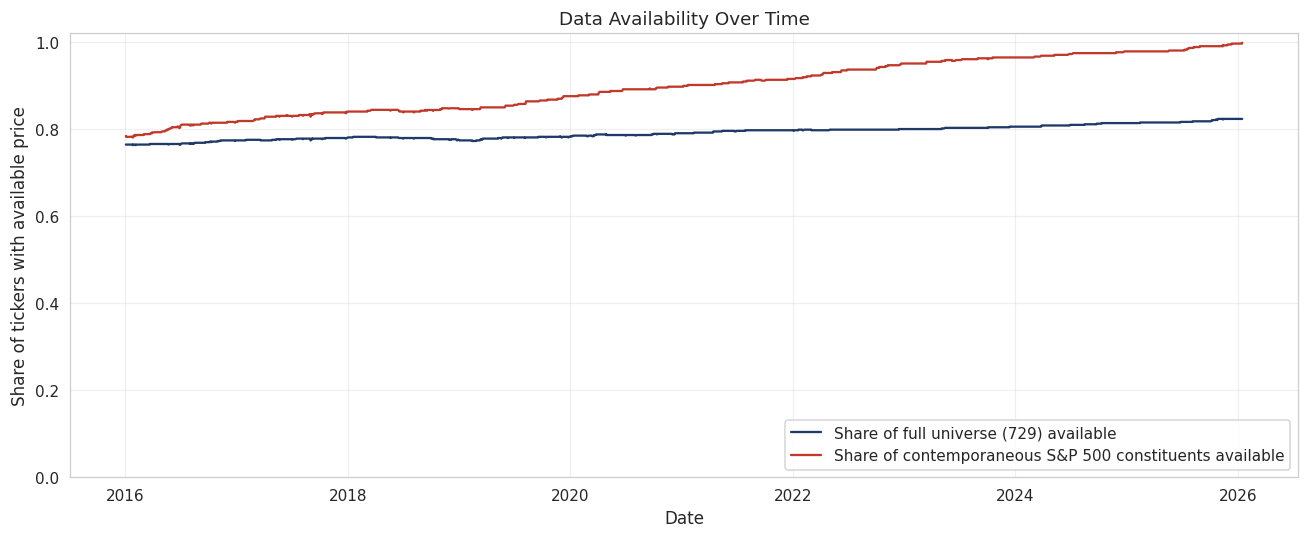

Universe coverage:
  Start of period (2016-01-04):  0.764
  End of period   (2026-01-14):  0.823

S&P 500 constituents coverage:
  Start of period:  0.784
  End of period:    0.998


In [56]:
universe_coverage = prices_daily.notna().sum(axis=1) / len(universe)

# Sort constituents by date for efficient lookup
constituents_sorted = constituents.sort_values('date').reset_index(drop=True)
available_yahoo = set(prices_daily.columns)


def constituents_on_date(d):
    """Return the list of original tickers that were S&P 500 constituents on date d."""
    idx = constituents_sorted['date'].searchsorted(d, side='right') - 1
    if idx < 0:
        return []
    tickers_str = constituents_sorted.iloc[idx]['tickers']
    return [t.strip() for t in tickers_str.split(',')]


trading_days = prices_daily.index
n_in_index       = pd.Series(index=trading_days, dtype=int)
n_in_index_avail = pd.Series(index=trading_days, dtype=int)

for d in trading_days:
    cons = constituents_on_date(d)
    n_in_index.loc[d] = len(cons)
    yahoo_cons = [to_yahoo_ticker(t) for t in cons if to_yahoo_ticker(t) in available_yahoo]
    n_in_index_avail.loc[d] = prices_daily.loc[d, yahoo_cons].notna().sum() if yahoo_cons else 0

constituents_coverage = n_in_index_avail / n_in_index


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(universe_coverage.index, universe_coverage.values,
        label='Share of full universe (729) available', color='#1f3a68', linewidth=1.5)
ax.plot(constituents_coverage.index, constituents_coverage.values,
        label='Share of contemporaneous S&P 500 constituents available',
        color='#c0392b', linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Share of tickers with available price')
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
ax.set_title('Data Availability Over Time')

plt.tight_layout()
plt.show()


print(f"Universe coverage:")
print(f"  Start of period (2016-01-04):  {universe_coverage.iloc[0]:.3f}")
print(f"  End of period   ({trading_days[-1].date()}):  {universe_coverage.iloc[-1]:.3f}")

print(f"\nS&P 500 constituents coverage:")
print(f"  Start of period:  {constituents_coverage.iloc[0]:.3f}")
print(f"  End of period:    {constituents_coverage.iloc[-1]:.3f}")

The second series rises from ~0.78 in 2016 to ~1.00 by 2026. This reflects residual survivorship bias: index members who left the index over the years (mainly via M&A) are no longer maintained by `yfinance`. The further back in time, the larger the share of index members whose price history is unavailable. By the end of the period, all current constituents are still actively trading and therefore fully covered.

#Data Visualization

**Exploratory Visualizations**

This section provides exploratory visualizations to characterize the data before moving to modeling. Four views are presented:

1. Index dynamics over the analysis period with major market events highlighted.
2. Market capitalization distribution within the current S&P 500.
3. Index returns compared against a naive equal-weighted portfolio.
4. Per-ticker data availability timelines.


**1) S&P 500 Total Return Index with Key Market Events**

The plot shows the cumulative dynamics of `^SP500TR` over 2016-2026, with vertical lines marking major market events. This sets the macroeconomic context for the analysis period: any tracking strategy will be evaluated against this exact path, including its drawdowns and recoveries.

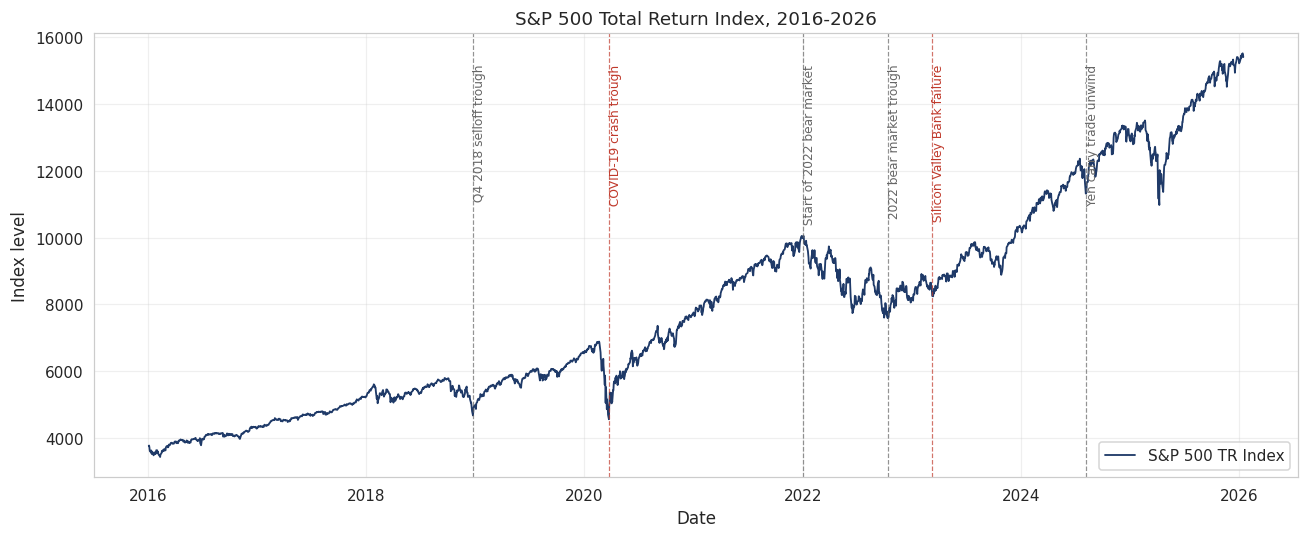

Index level start (2016-01-04):  3,763.99
Index level end   (2026-01-14): 15,408.15
Total return over period:  309.36%
Annualized return (CAGR):  15.09%


In [57]:
# Define key market events during the analysis period
events = [
    ('2018-12-24', 'Q4 2018 selloff trough',      '#666666'),
    ('2020-03-23', 'COVID-19 crash trough',       '#c0392b'),
    ('2022-01-03', 'Start of 2022 bear market',   '#666666'),
    ('2022-10-12', '2022 bear market trough',     '#666666'),
    ('2023-03-10', 'Silicon Valley Bank failure', '#c0392b'),
    ('2024-08-05', 'Yen carry trade unwind',      '#666666'),
]

index_close = index_data['Close']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(index_close.index, index_close.values,
        color='#1f3a68', linewidth=1.2, label='S&P 500 TR Index')

for date_str, label, color in events:
    d = pd.Timestamp(date_str)
    if index_close.index.min() <= d <= index_close.index.max():
        ax.axvline(d, color=color, linestyle='--', linewidth=0.8, alpha=0.7)
        ax.text(d, index_close.max() * 0.98, ' ' + label,
                rotation=90, va='top', ha='left', fontsize=8, color=color)

ax.set_title('S&P 500 Total Return Index, 2016-2026')
ax.set_xlabel('Date')
ax.set_ylabel('Index level')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Summary statistics
total_return = index_close.iloc[-1] / index_close.iloc[0] - 1
n_years = (index_close.index[-1] - index_close.index[0]).days / 365.25
cagr = (1 + total_return) ** (1 / n_years) - 1

print(f"Index level start ({index_close.index[0].date()}):  {index_close.iloc[0]:,.2f}")
print(f"Index level end   ({index_close.index[-1].date()}): {index_close.iloc[-1]:,.2f}")
print(f"Total return over period:  {total_return:.2%}")
print(f"Annualized return (CAGR):  {cagr:.2%}")

**Observations.**

Over the full analysis period (~10 years), the S&P 500 Total Return Index appreciated by roughly 310%, equivalent to a CAGR of approximately 15%. The path includes three notable drawdowns: the late-2018 selloff driven by rate hike expectations, the COVID-19 crash of March 2020 (the deepest but shortest), and the 2022 bear market caused by inflation and aggressive Fed tightening. Two episodes of acute financial stress — the March 2023 regional banking crisis and the August 2024 yen carry trade unwind — produced sharp but short-lived drawdowns. Any tracking strategy evaluated on this period must replicate these features at the corresponding frequency, not just the long-term trend.

**2) Market Capitalization Distribution within the S&P 500**

The S&P 500 is a free-float capitalization-weighted index. The distribution of these weights is highly skewed — a small number of mega-cap firms account for a disproportionate share of the index. This concentration is the central motivation for sparse index tracking: a portfolio with a small number of carefully chosen large-cap assets can plausibly replicate the index, while one that ignores the top holdings cannot match the index's dynamics.

**Data source.** I retrieve `marketCap` for each current constituent through `yfinance.Ticker(t).info`. This returns the total market capitalization rather than the free-float-adjusted value used in the actual index methodology; the two are typically very close for most large-cap firms. Public ETF holdings sources (slickcharts, iShares IVV) were attempted first but blocked by anti-bot protections, hence the per-ticker yfinance fallback.

Two views are plotted side by side:

1. **Top 30 constituents by weight** — bar chart showing concentration in the largest firms.
2. **Cumulative weight curve** — cumulative weight from heaviest to lightest constituent, with reference lines at top-10, top-50, and top-100.

Current S&P 500 constituents (as of 2026-01-14): 503


Market caps:   0%|          | 0/503 [00:00<?, ?it/s]

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}



Market caps retrieved: 502
Missing market caps:   1
Examples of missing:   ['DAY']

Total market cap covered: $72.75T

Top 10 by weight:
ticker    market_cap  weight_pct
  NVDA 5204124106752      7.1538
 GOOGL 4711453818880      6.4766
  GOOG 4662507339776      6.4093
  AAPL 4528552280064      6.2252
  MSFT 3090451791872      4.2483
  AMZN 2853753847808      3.9229
  AVGO 1998077427712      2.7467
  TSLA 1628444295168      2.2385
  META 1554378129408      2.1367
 BRK.B 1043097583616      1.4339


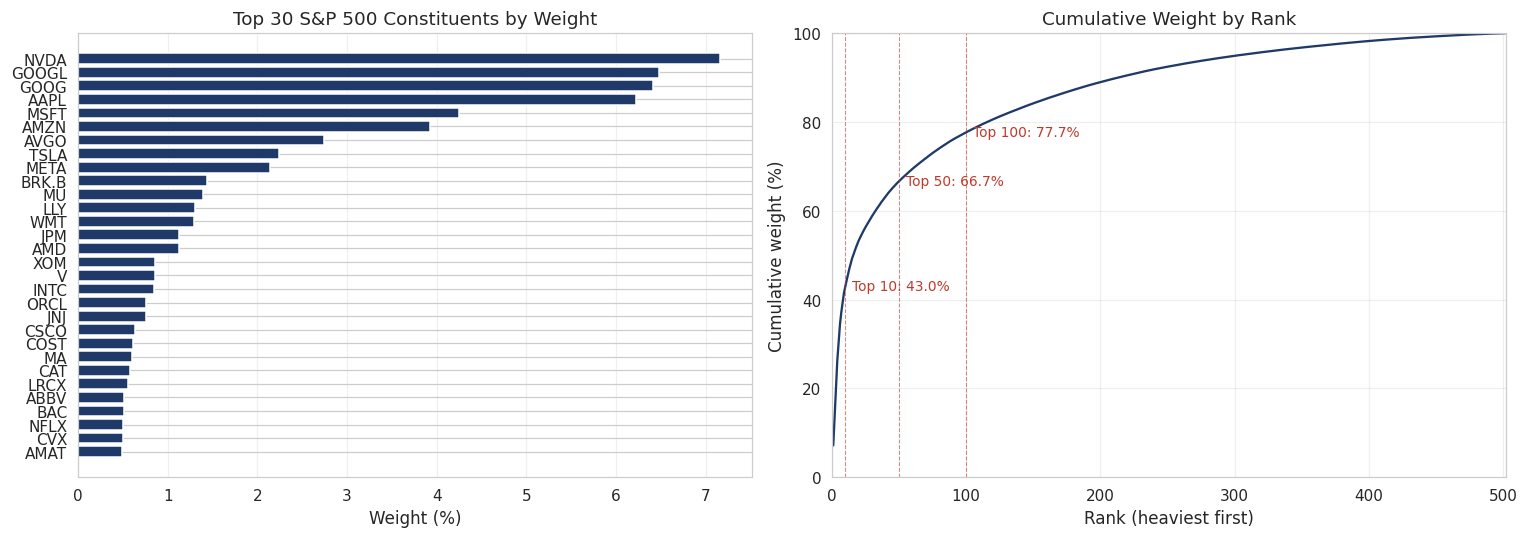


Concentration milestones:
  Top  16 firms cover 50% of the index
  Top  85 firms cover 75% of the index
  Top 214 firms cover 90% of the index
  Top 1 firm: NVDA (7.15%)
  Top 10 cumulative weight: 42.99%


In [58]:
# Get the current S&P 500 constituents (latest composition in our data)

latest_composition = constituents.iloc[-1]['tickers']
current_tickers_original = [t.strip() for t in latest_composition.split(',')]
print(f"Current S&P 500 constituents (as of {constituents.iloc[-1]['date'].date()}): "
      f"{len(current_tickers_original)}")


# Fetch market cap for each ticker via yfinance.Ticker.info

market_caps = {}
no_cap_tickers = []

for original_ticker in tqdm(current_tickers_original, desc='Market caps'):
    yahoo_ticker = to_yahoo_ticker(original_ticker)
    try:
        info = yf.Ticker(yahoo_ticker).info
        mcap = info.get('marketCap', None)
        if mcap is not None and mcap > 0:
            market_caps[original_ticker] = mcap
        else:
            no_cap_tickers.append(original_ticker)
    except Exception:
        no_cap_tickers.append(original_ticker)
    time.sleep(0.3)  # rate limiting

print(f"\nMarket caps retrieved: {len(market_caps)}")
print(f"Missing market caps:   {len(no_cap_tickers)}")
if no_cap_tickers:
    print(f"Examples of missing:   {no_cap_tickers[:10]}")


# Build the weights DataFrame

weights = pd.DataFrame({
    'ticker': list(market_caps.keys()),
    'market_cap': list(market_caps.values()),
})
weights['weight_pct'] = weights['market_cap'] / weights['market_cap'].sum() * 100
weights = weights.sort_values('weight_pct', ascending=False).reset_index(drop=True)

print(f"\nTotal market cap covered: ${weights['market_cap'].sum() / 1e12:.2f}T")
print(f"\nTop 10 by weight:")
print(weights.head(10).to_string(index=False))


# Plot two views side by side

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))

# Left: top 30 weights as a horizontal bar chart
top_n = 30
top = weights.head(top_n).iloc[::-1]
ax_left.barh(top['ticker'], top['weight_pct'], color='#1f3a68', edgecolor='white')
ax_left.set_title(f'Top {top_n} S&P 500 Constituents by Weight')
ax_left.set_xlabel('Weight (%)')
ax_left.grid(True, axis='x', alpha=0.3)

# Right: cumulative weight curve
cumulative = weights['weight_pct'].cumsum().values
rank = np.arange(1, len(weights) + 1)
ax_right.plot(rank, cumulative, color='#1f3a68', linewidth=1.5)

for n in [10, 50, 100]:
    if n <= len(cumulative):
        cw = cumulative[n - 1]
        ax_right.axvline(n, color='#c0392b', linestyle='--', linewidth=0.7, alpha=0.6)
        ax_right.text(n + 5, cw, f'Top {n}: {cw:.1f}%', fontsize=9, color='#c0392b',
                      verticalalignment='center')

ax_right.set_title('Cumulative Weight by Rank')
ax_right.set_xlabel('Rank (heaviest first)')
ax_right.set_ylabel('Cumulative weight (%)')
ax_right.set_xlim(0, len(weights))
ax_right.set_ylim(0, 100)
ax_right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Concentration milestones

def n_firms_for_threshold(cumulative_arr, threshold):
    """Number of top firms required to reach a given cumulative weight."""
    above = (cumulative_arr >= threshold).nonzero()[0]
    return int(above[0]) + 1 if len(above) > 0 else len(cumulative_arr)

n_50 = n_firms_for_threshold(cumulative, 50)
n_75 = n_firms_for_threshold(cumulative, 75)
n_90 = n_firms_for_threshold(cumulative, 90)

print(f"\nConcentration milestones:")
print(f"  Top {n_50:>3} firms cover 50% of the index")
print(f"  Top {n_75:>3} firms cover 75% of the index")
print(f"  Top {n_90:>3} firms cover 90% of the index")
print(f"  Top 1 firm: {weights.iloc[0]['ticker']} ({weights.iloc[0]['weight_pct']:.2f}%)")
print(f"  Top 10 cumulative weight: {cumulative[9]:.2f}%")

**Observations.**

The S&P 500 is highly concentrated in mega-cap technology firms. NVIDIA alone accounts for 7.15% of the index, and the top 5 names (NVIDIA, Alphabet's two share classes, Apple, Microsoft) together exceed 30%. Out of 503 constituents, just 16 firms cover half of the total weight; only 85 firms are needed to reach 75%, and 214 firms cover 90%. The bottom ~290 constituents jointly contribute less than 10% of the index.

This skew has two implications for the project. First, it justifies sparse index tracking as a meaningful problem: a portfolio of 30-50 carefully chosen large-cap assets can plausibly replicate the index dynamics, since these assets carry most of the weight. Second, it warns about a risk: a sparse portfolio that simply selects top-K by weight will be heavily exposed to a single sector (Technology), and its tracking error during sector-specific shocks may be elevated. A robust sparse tracking method should balance weight coverage and sector diversification.

**3) Cap-Weighted vs Equal-Weighted S&P 500**

To illustrate the impact of concentration on index dynamics, I compare two versions of the same universe with different weighting schemes:

- **SPY** (SPDR S&P 500 ETF) — tracks the cap-weighted S&P 500. Mega-cap firms dominate.
- **RSP** (Invesco S&P 500 Equal Weight ETF) — tracks the equal-weighted S&P 500. Each of the ~500 constituents has approximately equal weight, rebalanced quarterly.

Both ETFs follow total-return methodology (dividends reinvested), so the comparison is methodologically clean. ETFs were chosen rather than raw indices because Yahoo Finance does not maintain the Total Return version of the equal-weighted index, while ETFs provide an "investable" representation of both strategies with consistent dividend treatment.

The plot shows cumulative returns from both ETFs over the analysis period, both normalized to 1.0 at the start. The gap between the two lines is a direct, model-free demonstration of how mega-cap concentration has driven S&P 500 returns in recent years.

Period: 2016-01-04 to 2026-01-14
Observations: 2523


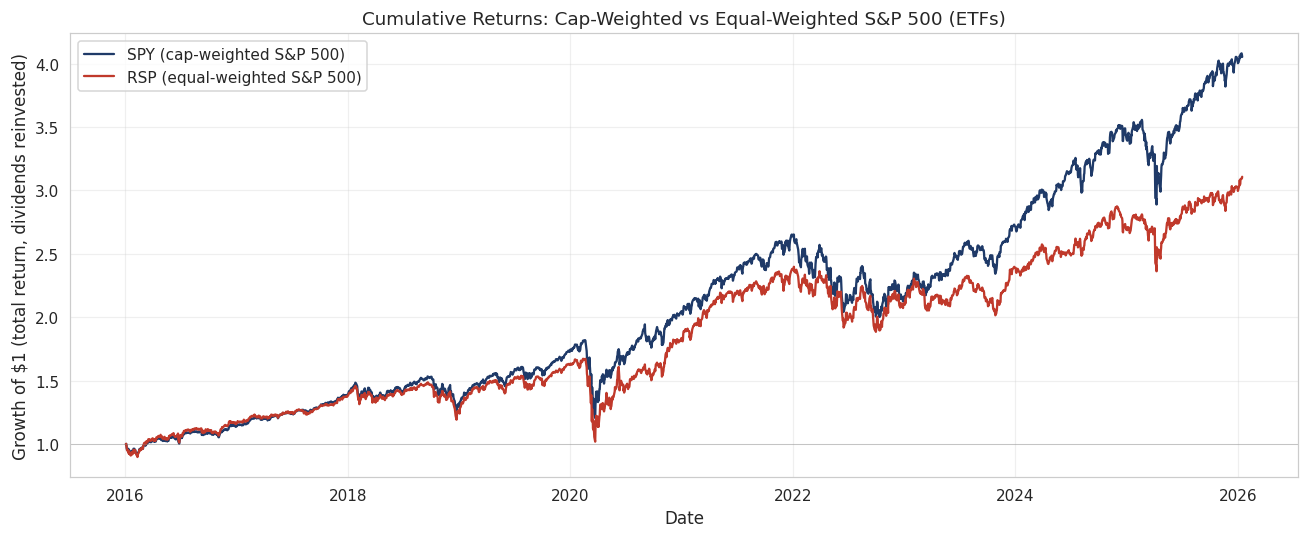


Performance summary (2016-01-04 to 2026-01-14):
                                        SPY          RSP    Δ (SPY-RSP)
                  Total return      305.21%      210.74%         94.47pp
      Annualized return (CAGR)       14.97%       11.97%          3.00pp
         Annualized volatility       17.98%       18.49%         -0.51pp


In [59]:
# Download both ETFs (auto_adjust gives total return)

etf_data = yf.download(
    ['SPY', 'RSP'],
    start=START_DATE,
    end=END_DATE + pd.Timedelta(days=1),
    auto_adjust=True,
    progress=False,
    threads=False,
    group_by='ticker',
)

spy_close = etf_data['SPY']['Close'].dropna()
rsp_close = etf_data['RSP']['Close'].dropna()

# Align on common dates
common_dates = spy_close.index.intersection(rsp_close.index)
spy_close = spy_close.loc[common_dates]
rsp_close = rsp_close.loc[common_dates]

print(f"Period: {common_dates.min().date()} to {common_dates.max().date()}")
print(f"Observations: {len(common_dates)}")


# Normalize to start at 1.0

spy_norm = spy_close / spy_close.iloc[0]
rsp_norm = rsp_close / rsp_close.iloc[0]


# Plot cumulative returns

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(spy_norm.index, spy_norm.values,
        label='SPY (cap-weighted S&P 500)', color='#1f3a68', linewidth=1.5)
ax.plot(rsp_norm.index, rsp_norm.values,
        label='RSP (equal-weighted S&P 500)', color='#c0392b', linewidth=1.5)

ax.set_title('Cumulative Returns: Cap-Weighted vs Equal-Weighted S&P 500 (ETFs)')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 (total return, dividends reinvested)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.axhline(1.0, color='gray', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()


# Performance comparison

def annualized_return(series):
    """Compute the annualized return from a price series."""
    total = series.iloc[-1] / series.iloc[0] - 1
    years = (series.index[-1] - series.index[0]).days / 365.25
    return (1 + total) ** (1 / years) - 1


def annualized_volatility(series):
    """Compute the annualized volatility from daily returns."""
    daily_returns = series.pct_change().dropna()
    return daily_returns.std() * np.sqrt(252)


print(f"\nPerformance summary ({common_dates.min().date()} to {common_dates.max().date()}):")
print(f"{'':>30s} {'SPY':>12s} {'RSP':>12s} {'Δ (SPY-RSP)':>14s}")
print(f"{'Total return':>30s} "
      f"{(spy_close.iloc[-1] / spy_close.iloc[0] - 1) * 100:>11.2f}% "
      f"{(rsp_close.iloc[-1] / rsp_close.iloc[0] - 1) * 100:>11.2f}% "
      f"{((spy_close.iloc[-1] / spy_close.iloc[0]) - (rsp_close.iloc[-1] / rsp_close.iloc[0])) * 100:>13.2f}pp")
print(f"{'Annualized return (CAGR)':>30s} "
      f"{annualized_return(spy_close) * 100:>11.2f}% "
      f"{annualized_return(rsp_close) * 100:>11.2f}% "
      f"{(annualized_return(spy_close) - annualized_return(rsp_close)) * 100:>13.2f}pp")
print(f"{'Annualized volatility':>30s} "
      f"{annualized_volatility(spy_close) * 100:>11.2f}% "
      f"{annualized_volatility(rsp_close) * 100:>11.2f}% "
      f"{(annualized_volatility(spy_close) - annualized_volatility(rsp_close)) * 100:>13.2f}pp")

**Observations.**

The two strategies diverge dramatically over the analysis period. SPY (cap-weighted) delivered a total return of **305%** versus RSP (equal-weighted) at **211%** — a gap of 94 percentage points over ten years, or **3.00 pp** in annualized terms (14.97% vs 11.97% CAGR).

The chart reveals three distinct regimes:

1. **2016 to end-2021:** The two strategies track each other closely, occasionally with the equal-weighted version slightly ahead. Mega-cap concentration was not yet the dominant driver.
2. **2022:** RSP underperforms during the bear market — equal weighting tilts the portfolio toward smaller-cap names, which are more sensitive to recession fears.
3. **2023-2025:** SPY pulls sharply ahead. This corresponds to the AI-driven rally in mega-cap technology stocks (the "Magnificent 7"), which collectively gained hundreds of percent and lifted the cap-weighted index disproportionately. Equal-weighted captured only the median performance and missed the concentration premium.

Two takeaways for the project. First, **a sparse tracking portfolio that ignores the top weights cannot replicate the cap-weighted S&P 500 in periods of mega-cap dominance** — the bulk of recent index returns came from a handful of names. Second, the comparable annualized volatility of both strategies (17.98% vs 18.49%) suggests that the diversification benefit of equal weighting is more about return composition than risk reduction. Any sparse tracking method must therefore reproduce both the trend and the concentration structure of the cap-weighted benchmark.

**Per-Ticker Data Availability Timeline**

This plot visualizes the active period of each ticker in the universe — from the first observation date to the last. Tickers with complete history over the full analysis window (~558 tickers, coverage_full_period > 99%) are excluded to focus on the heterogeneous part of the universe: companies that entered the data via IPO or spin-off during the period, or exited via M&A or delisting.

Each horizontal segment represents one ticker, color-coded by its situation:

- **Right-truncated** (line ends before 2026): companies removed from the index and delisted during the period (e.g., M&A targets, bankruptcies).
- **Left-truncated** (line starts after 2016): companies that joined the data later (IPOs, spin-offs).
- **Both ends truncated**: short-lived members of the index.

The chart provides an intuitive view of the temporal heterogeneity of the universe and identifies the periods in which the in-sample candidate pool was most volatile.

Tickers with full history (excluded from plot): 546
Tickers with partial history (shown on plot):   66

Category breakdown:
category
Left-truncated (entered later)    54
Right-truncated (delisted)        11
Both truncated                     1


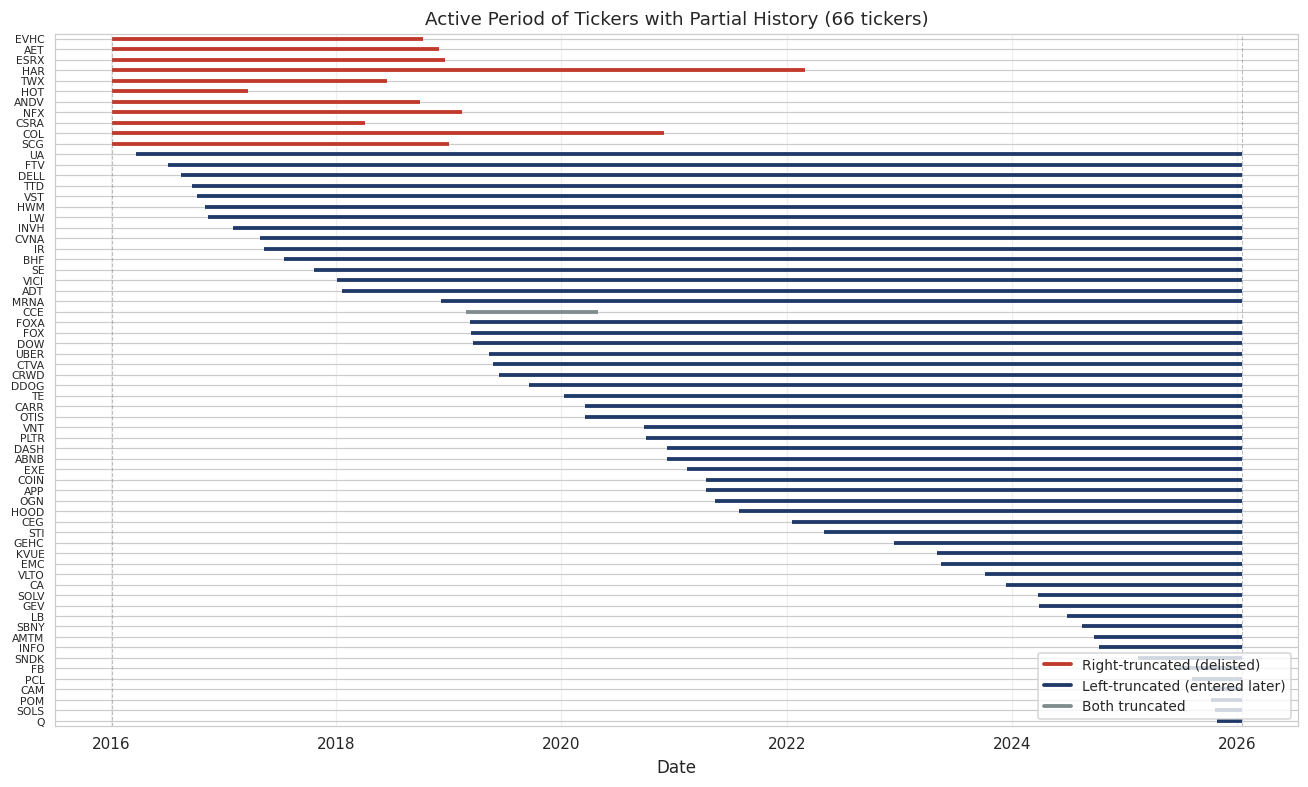

In [60]:
# Select tickers with non-full history

avail = ticker_availability[ticker_availability['available']].copy()
partial = avail[avail['coverage_full_period'] < 0.99].copy()

print(f"Tickers with full history (excluded from plot): {(avail['coverage_full_period'] >= 0.99).sum()}")
print(f"Tickers with partial history (shown on plot):   {len(partial)}")


# Classify each partial-history ticker

period_start = prices_daily.index.min()
period_end   = prices_daily.index.max()
buffer = pd.Timedelta(days=14)

def classify(row):
    left_truncated  = row['first_date'] > period_start + buffer
    right_truncated = row['last_date']  < period_end   - buffer
    if left_truncated and right_truncated:
        return 'Both truncated'
    if left_truncated:
        return 'Left-truncated (entered later)'
    if right_truncated:
        return 'Right-truncated (delisted)'
    return 'Other'

partial['category'] = partial.apply(classify, axis=1)
print(f"\nCategory breakdown:")
print(partial['category'].value_counts().to_string())


# Sort: latest first_date at the bottom (y=0), earliest first_date at the top

partial = partial.sort_values('first_date', ascending=False).reset_index(drop=True)


# Plot horizontal lines

color_map = {
    'Right-truncated (delisted)':     '#c0392b',
    'Left-truncated (entered later)': '#1f3a68',
    'Both truncated':                 '#7f8c8d',
    'Other':                          '#95a5a6',
}

fig, ax = plt.subplots(figsize=(12, max(6, len(partial) * 0.11)))

for i, row in partial.iterrows():
    ax.plot(
        [row['first_date'], row['last_date']],
        [i, i],
        color=color_map[row['category']],
        linewidth=2.5,
        solid_capstyle='butt',
    )

# Labels on the y-axis: ticker symbols
ax.set_yticks(range(len(partial)))
ax.set_yticklabels(partial['ticker'], fontsize=7)
ax.set_ylim(-0.5, len(partial) - 0.5)

# Reference lines: period boundaries
ax.axvline(period_start, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.axvline(period_end,   color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

ax.set_xlabel('Date')
ax.set_title(f'Active Period of Tickers with Partial History ({len(partial)} tickers)')
ax.grid(True, axis='x', alpha=0.3)

# Legend
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=color, linewidth=2.5, label=label)
           for label, color in color_map.items()
           if label in partial['category'].unique()]
ax.legend(handles=handles, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

**Observations.**

The chart shows 66 tickers with partial history in the universe, naturally splitting into two groups corresponding to two types of index turnover.

**Right-truncated tickers (red, 12 cases):** companies that were removed from the index and delisted during the period — predominantly via M&A. A cluster around 2018-2019 reflects a wave of mergers and acquisitions: Time Warner (TWX, acquired by AT&T), Aetna (AET, CVS), Express Scripts (ESRX, Cigna), Andeavor (ANDV, Marathon), Envision Healthcare (EVHC), and others. Two tickers (HAR, COL) extend visibly beyond their delisting dates, consistent with the symbol reuse phenomenon discussed earlier — their late observations correspond to different securities that subsequently received the same ticker symbol.

**Left-truncated tickers (dark blue, 53 cases):** companies that joined the data later via IPO or spin-off. Several distinct waves are visible:
- *2019-2020 IPO wave:* UBER, CRWD, DDOG, DASH, ABNB — the cohort of large tech IPOs of that period.
- *2020 UTC spin-offs:* CARR (Carrier) and OTIS (Otis Elevator), separated from United Technologies.
- *2022-2024 spin-off wave:* CEG (from Exelon), KVUE (from J&J), GEHC (from GE), GEV (from GE), VLTO (from Danaher), SOLV (from 3M) — a notable concentration of corporate separations driven by tax and strategic considerations.

**Both-truncated (gray, 1 case):** the `CCE` ticker discussed earlier, with a short and inconsistent active window. This ticker is excluded from the modeling universe in the final preprocessing step.

The visualization makes explicit a key practical point: at any historical point of analysis, the in-sample candidate pool is not a fixed set of 612 names but rather a time-varying subset. A tracking model evaluated at, say, March 2018 cannot select from UBER, CARR, ABNB, or any other ticker that had not yet started trading. This time-dependence of the available universe is a central operational constraint of point-in-time backtesting.

#Data Export

**Final Preprocessing and Files Saving**

This section produces the ML-ready dataset for the next notebook. The pipeline:

1. **Filter the universe.** Exclude `CCE` based on the coverage diagnostic (single anomaly with `coverage_from_first = 0.466` and prices inconsistent with the historical S&P 500 constituent under this symbol). All other 611 loaded tickers are retained.

2. **Resample to weekly frequency.** Daily prices are downsampled to weekly using a Friday-close convention (`W-FRI` + `.last()`), which is the industry standard for index tracking studies and matches the natural reporting frequency of weekly equity returns.

3. **Compute simple returns.** Weekly simple returns `r_t = P_t / P_{t-1} - 1` are computed for both the asset universe and the index. Simple returns (rather than log returns) are used because weighted sums of asset returns equal portfolio returns, which is the central identity for index tracking optimization.

4. **Align dates.** The asset returns and the index returns are aligned on a common weekly date index. The first observation (with NaN return) is dropped.

5. **Persist artifacts.** All key DataFrames are saved to Google Drive in Parquet format. The next notebook consumes these as inputs and does not need to re-run any data collection step.


In [61]:
EXCLUDED_TICKERS = {'CCE'}


# Filter the universe

available_tickers_original = [
    t for t in universe
    if to_yahoo_ticker(t) in prices_daily.columns and t not in EXCLUDED_TICKERS
]
available_tickers_yahoo = [to_yahoo_ticker(t) for t in available_tickers_original]

prices_daily_filtered = prices_daily[available_tickers_yahoo].copy()

print(f"Universe before filtering: {prices_daily.shape[1]}")
print(f"Universe after filtering:  {prices_daily_filtered.shape[1]}")
print(f"Excluded tickers: {sorted(EXCLUDED_TICKERS)}")


# Resample to weekly

prices_weekly = prices_daily_filtered.resample('W-FRI').last()
index_close_daily = index_data['Close']
index_weekly = index_close_daily.resample('W-FRI').last()

# Compute simple returns

returns_weekly = prices_weekly.pct_change()
index_returns_weekly = index_weekly.pct_change()

# Drop the first row, which is NaN by construction
returns_weekly = returns_weekly.iloc[1:]
index_returns_weekly = index_returns_weekly.iloc[1:]


# Align dates between asset returns and index returns

common_dates = returns_weekly.index.intersection(index_returns_weekly.index)
returns_weekly = returns_weekly.loc[common_dates]
index_returns_weekly = index_returns_weekly.loc[common_dates]

print(f"\nFinal aligned dataset:")
print(f"  Weekly observations: {len(common_dates)}")
print(f"  Date range:          {common_dates.min().date()} to {common_dates.max().date()}")
print(f"  Asset universe:      {returns_weekly.shape[1]}")


# Persist all artifacts to Google Drive

# Raw data (kept for transparency and reproducibility)
prices_daily.to_parquet(f'{PROJECT_DIR}/prices_daily_raw.parquet')
index_data.to_parquet(f'{PROJECT_DIR}/index_data_raw.parquet')

# Reference tables
constituents.to_parquet(f'{PROJECT_DIR}/constituents.parquet')
index_changes.to_parquet(f'{PROJECT_DIR}/index_changes.parquet')
ticker_availability.to_parquet(f'{PROJECT_DIR}/ticker_availability.parquet')

# Failed tickers (documents the residual survivorship bias)
failed_df = pd.DataFrame(failed_tickers, columns=['yahoo_ticker', 'reason'])
failed_df['original_ticker'] = failed_df['yahoo_ticker'].map(yf_to_original)
failed_df = failed_df[['original_ticker', 'yahoo_ticker', 'reason']]
failed_df.to_csv(f'{PROJECT_DIR}/failed_tickers.csv', index=False)

# ML-ready preprocessed data
returns_weekly.to_parquet(f'{PROJECT_DIR}/returns_weekly.parquet')
index_returns_weekly.to_frame('return').to_parquet(f'{PROJECT_DIR}/index_returns_weekly.parquet')

# Universe list (original ticker names, after filtering)
with open(f'{PROJECT_DIR}/universe_filtered.txt', 'w') as f:
    f.write('\n'.join(available_tickers_original))


# Summary of saved files

print(f"\nSaved files to {PROJECT_DIR}:")
print(f"  prices_daily_raw.parquet         {prices_daily.shape}")
print(f"  index_data_raw.parquet           {index_data.shape}")
print(f"  constituents.parquet             {constituents.shape}")
print(f"  index_changes.parquet            {index_changes.shape}")
print(f"  ticker_availability.parquet      {ticker_availability.shape}")
print(f"  failed_tickers.csv               {failed_df.shape}")
print(f"  returns_weekly.parquet           {returns_weekly.shape}    [ML-READY]")
print(f"  index_returns_weekly.parquet     ({len(index_returns_weekly)},)  [ML-READY]")
print(f"  universe_filtered.txt            {len(available_tickers_original)} tickers")

Universe before filtering: 612
Universe after filtering:  611
Excluded tickers: ['CCE']

Final aligned dataset:
  Weekly observations: 523
  Date range:          2016-01-15 to 2026-01-16
  Asset universe:      611

Saved files to /content/drive/MyDrive/ml_finance_project_index_tracking:
  prices_daily_raw.parquet         (2523, 612)
  index_data_raw.parquet           (2523, 5)
  constituents.parquet             (475, 2)
  index_changes.parquet            (417, 6)
  ticker_availability.parquet      (729, 8)
  failed_tickers.csv               (117, 3)
  returns_weekly.parquet           (523, 611)    [ML-READY]
  index_returns_weekly.parquet     (523,)  [ML-READY]
  universe_filtered.txt            611 tickers


Finally, let's examine what data each of these files contains.

In [62]:
artifacts = [
    ('prices_daily_raw.parquet',      'Daily prices (raw, all 612 loaded tickers)'),
    ('index_data_raw.parquet',        'S&P 500 TR index OHLCV (daily, raw)'),
    ('constituents.parquet',          'Historical S&P 500 constituents (point-in-time)'),
    ('index_changes.parquet',         'Index change events with classified reasons'),
    ('ticker_availability.parquet',   'Per-ticker availability and coverage metrics'),
    ('returns_weekly.parquet',        'Weekly simple returns of the filtered universe [ML-READY]'),
    ('index_returns_weekly.parquet',  'Weekly simple returns of the index [ML-READY]'),
]

for filename, description in artifacts:
    path = f'{PROJECT_DIR}/{filename}'
    df = pd.read_parquet(path)
    print('=' * 80)
    print(f'{filename}')
    print(f'  Description: {description}')
    print(f'  Shape:       {df.shape}')
    print(f'  Columns:     {df.columns.tolist()[:8]}'
          f'{" ..." if df.shape[1] > 8 else ""}')
    print(f'  Index name:  {df.index.name}')
    print(f'  Index dtype: {df.index.dtype}')
    print(f'  Head:')
    print(df.head(5).to_string())
    print()

print('=' * 80)
print('failed_tickers.csv')
failed_preview = pd.read_csv(f'{PROJECT_DIR}/failed_tickers.csv')
print(f'  Shape: {failed_preview.shape}')
print(f'  Head:')
print(failed_preview.head(5).to_string())
print()

print('=' * 80)
print('universe_filtered.txt')
with open(f'{PROJECT_DIR}/universe_filtered.txt', 'r') as f:
    tickers = [line.strip() for line in f.readlines()]
print(f'  Total tickers: {len(tickers)}')
print(f'  First 10:      {tickers[:10]}')
print(f'  Last 10:       {tickers[-10:]}')

prices_daily_raw.parquet
  Description: Daily prices (raw, all 612 loaded tickers)
  Shape:       (2523, 612)
  Columns:     ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL'] ...
  Index name:  Date
  Index dtype: datetime64[ns]
  Head:
                 A     AAL      AAP    AAPL    ABBV  ABNB     ABT    ACGL     ACN    ADBE     ADI     ADM     ADP    ADSK  ADT     AEE     AEP    AES      AET     AFL     AIG    AIV     AIZ     AJG    AKAM     ALB    ALGN     ALK     ALL    ALLE    AMAT    AMCR    AMD     AME      AMG     AMGN     AMP     AMT  AMTM    AMZN      AN     ANDV   ANET     AON     AOS     APA     APD     APH    APO  APP    APTV     ARE   ARES     ATO      AVB    AVGO     AVY     AWK    AXON     AXP      AYI      AZO       BA     BAC    BALL     BAX    BBBY     BBT    BBWI     BBY     BDX     BEN    BF-B      BG  BHF     BIIB      BIO      BK    BKNG     BKR    BLDR      BLK     BMY      BR    BRK-B     BRO     BSX     BWA      BX     BXP       C  CA     CAG     CAH  